In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [23]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [29]:
ST_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
ST_event = EDM4hepEvent(ST_file_path, event_index=0, detector_params=detector_params)
ST_particles = ST_event.get_particles_df()
ST_hits = ST_event.get_tracker_hits_df()
ST_calo_hits = ST_event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root...
  Loaded 25 particles.
  Loaded 13 tracker hits.
  Loaded 112 calo hits and 301 contributions.


## Plotting

In [30]:
ST_tracker_reco_particles = ST_particles[ST_particles.index.isin(ST_hits.particle_id)]

In [31]:
ST_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,3.552404,0.105658,-0.005444,0.010871,100.027569,6.573239,...,-0.144718,0.012158,9874.388107,10.000558,9.8949,162,False,True,False,False


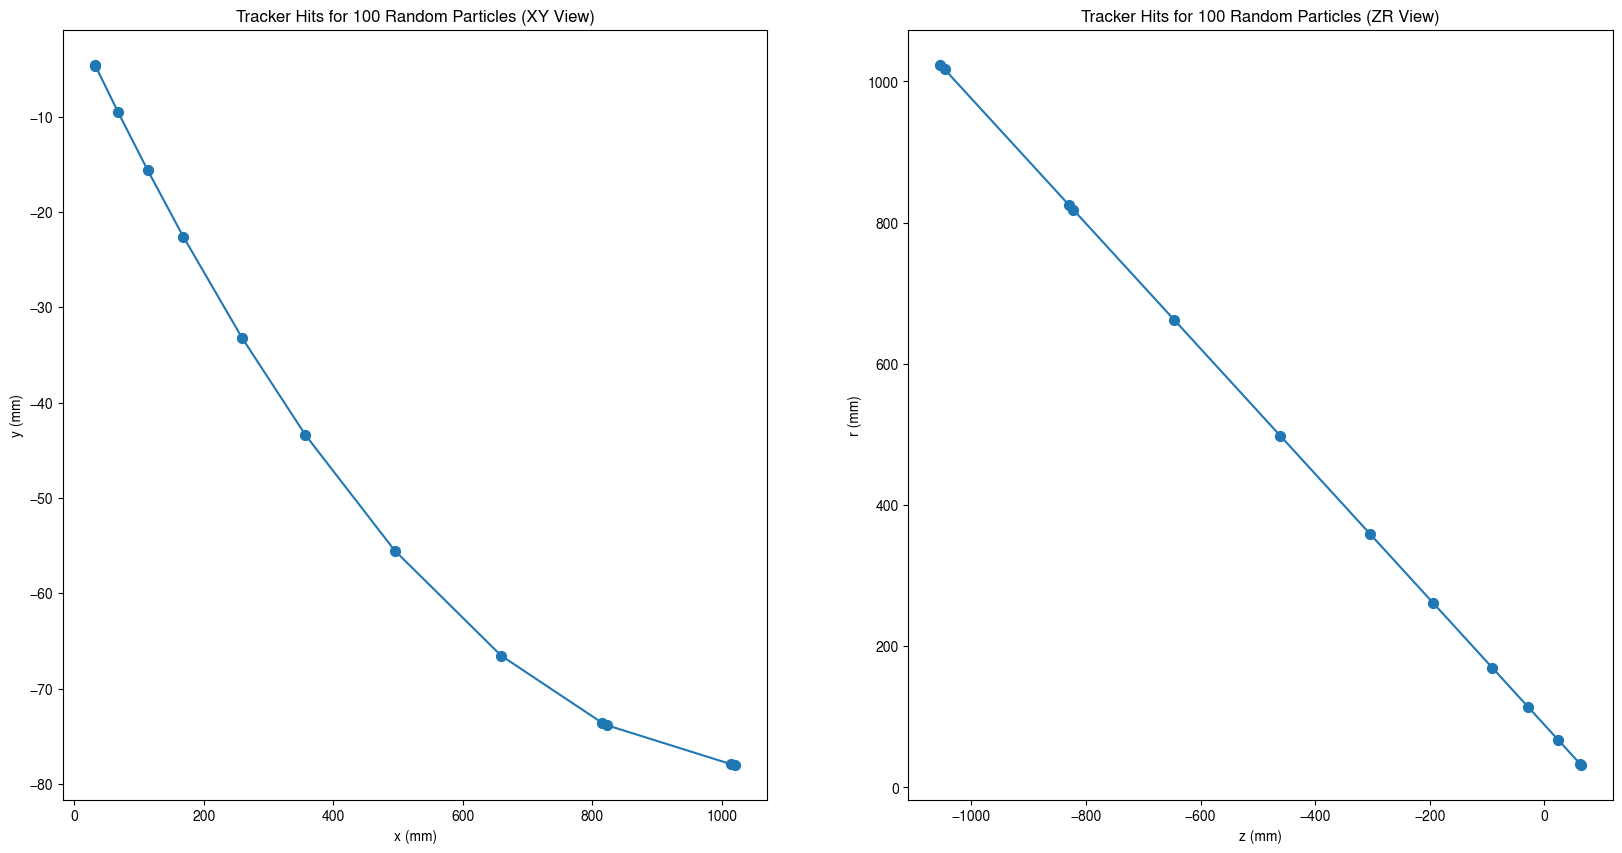

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in ST_tracker_reco_particles.index:
    particle_hits = ST_hits[ST_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

## Loading

In [33]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [34]:
MT_file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root"
MT_event = EDM4hepEvent(MT_file_path, event_index=0, detector_params=detector_params)
MT_particles = MT_event.get_particles_df()
MT_hits = MT_event.get_tracker_hits_df()
MT_calo_hits = MT_event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v4/runs/all/edm4hep.root...
  Loaded 13 particles.
  Loaded 14 tracker hits.
  Loaded 100 calo hits and 219 contributions.


## Plotting

In [35]:
MT_tracker_reco_particles = MT_particles[MT_particles.index.isin(MT_hits.particle_id)]

In [40]:
ST_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,3.552404,0.105658,-0.005444,0.010871,100.027569,6.573239,...,-0.144718,0.012158,9874.388107,10.000558,9.8949,162,False,True,False,False


In [36]:
MT_tracker_reco_particles

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,phi,vr,endpoint_r,energy,kinetic_energy,num_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,13,1,33554432,-1.0,6.98568,0.105658,-0.014666,0.010754,-12.013482,2.722971,...,-0.943378,0.018186,5190.164522,10.000558,9.8949,163,False,True,False,False


In [38]:
ST_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,37798480908038,3.714610,0.189893,0,31.903724,-4.569434,63.750438,6.575960,-0.930159,-7.475188,0.000051,0,PixelBarrelReadout,32.229293,71.434205,-0.142258,0.468081,1.433766,6.641418
1,36557252132870,3.718923,0.194695,0,32.752388,-4.689248,62.785746,6.576090,-0.929369,-7.475060,0.000115,0,PixelBarrelReadout,33.086372,70.970119,-0.142206,0.484992,1.396895,6.641437
2,264227747471126,3.893423,0.188512,0,67.169270,-9.478984,23.679706,6.579893,-0.900346,-7.473955,0.000043,0,PixelBarrelReadout,67.834813,71.849081,-0.140195,1.234942,0.342352,6.641205
3,10376087745318,4.127457,0.189791,0,113.352857,-15.633911,-28.772379,6.583920,-0.856024,-7.474353,0.000059,0,PixelBarrelReadout,114.425912,117.987877,-0.137058,1.817139,-0.248873,6.639336
4,24465795009590,4.404902,0.188705,0,168.176999,-22.585320,-90.929327,6.592319,-0.811496,-7.470341,0.000094,0,PixelBarrelReadout,169.686769,192.514265,-0.133496,2.062723,-0.513059,6.642077
5,809687235176201,4.865090,0.307066,0,259.160468,-33.226033,-193.999729,6.597077,-0.730838,-7.470675,0.000094,0,ShortStripBarrelReadout,261.281682,325.428966,-0.127511,2.209475,-0.687130,6.637435
6,756279316789017,5.358710,0.305388,0,356.905692,-43.402482,-304.630169,6.602338,-0.643237,-7.470876,0.000379,0,ShortStripBarrelReadout,359.535045,471.237720,-0.121014,2.273715,-0.769171,6.633598
7,71141902715866409,6.054161,0.304876,0,494.789389,-55.524487,-460.528406,6.611061,-0.517741,-7.471029,0.000101,0,ShortStripBarrelReadout,497.895077,678.222619,-0.111751,2.317227,-0.827298,6.631303
8,176789444125753,6.881642,0.308628,0,659.078770,-66.541154,-646.051005,6.618472,-0.370135,-7.471860,0.000084,0,ShortStripBarrelReadout,662.429279,925.307760,-0.100620,2.343678,-0.863782,6.628813
9,528152128535308,7.667611,0.386151,0,815.241304,-73.601172,-822.284801,6.624163,-0.229006,-7.472286,0.000108,0,LongStripBarrelReadout,818.556972,1160.253339,-0.090037,2.358466,-0.884590,6.628120


In [39]:
MT_hits

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,48449865452806,7.217683,0.271529,0,18.967621,-25.993425,-73.508583,2.745815,-3.737708,-8.858850,0.000064,0,PixelBarrelReadout,32.178079,80.243009,-0.940409,2.728976,-1.564053,4.637883
1,45834230369798,7.225061,0.279653,0,19.574396,-26.818308,-75.464250,2.746863,-3.737904,-8.858284,0.000077,0,PixelBarrelReadout,33.202088,82.445325,-0.940291,2.727110,-1.559410,4.638661
2,236258668649238,7.474339,0.269920,0,40.226257,-54.684860,-141.659935,2.776260,-3.718737,-8.855777,0.000154,0,PixelBarrelReadout,67.886565,157.086355,-0.936574,2.694705,-1.481757,4.640757
3,33673953094694,7.804231,0.270106,0,67.857447,-91.327903,-229.259764,2.810090,-3.690714,-8.854856,0.000068,0,PixelBarrelReadout,113.777937,255.940341,-0.931785,2.680922,-1.450313,4.638747
4,268695536550454,8.204579,0.269694,0,101.846822,-135.488907,-335.552190,2.849865,-3.662588,-8.850487,0.000080,0,PixelBarrelReadout,169.499319,375.932562,-0.926209,2.673845,-1.434505,4.640720
5,264430315258678,8.216426,0.271890,0,102.859907,-136.789722,-338.696310,2.850656,-3.662033,-8.850257,0.000084,0,PixelBarrelReadout,171.147856,379.482251,-0.926044,2.673703,-1.434190,4.640767
6,1126277864301065,8.862869,0.439353,0,158.716523,-207.289375,-510.250739,2.913103,-3.611692,-8.846022,0.000135,0,ShortStripBarrelReadout,261.074357,573.162836,-0.917338,2.668661,-1.423067,4.640096
7,70421310282674201,9.569820,0.437418,0,221.243076,-283.312791,-697.931292,2.982242,-3.552258,-8.845210,0.000140,0,ShortStripBarrelReadout,359.464374,785.062242,-0.907802,2.665983,-1.417203,4.638135
8,421980536914729,10.575931,0.438612,0,312.758358,-389.354252,-965.037226,3.079354,-3.467810,-8.843506,0.000146,0,ShortStripBarrelReadout,499.414181,1086.605435,-0.894062,2.664037,-1.412960,4.637686
9,785979052554,11.809100,0.282288,0,428.911899,-515.807934,-1292.500000,3.194134,-3.362578,-8.843224,0.000099,0,ShortStripEndcapReadout,670.837716,1456.220962,-0.877121,2.662842,-1.410364,4.637825


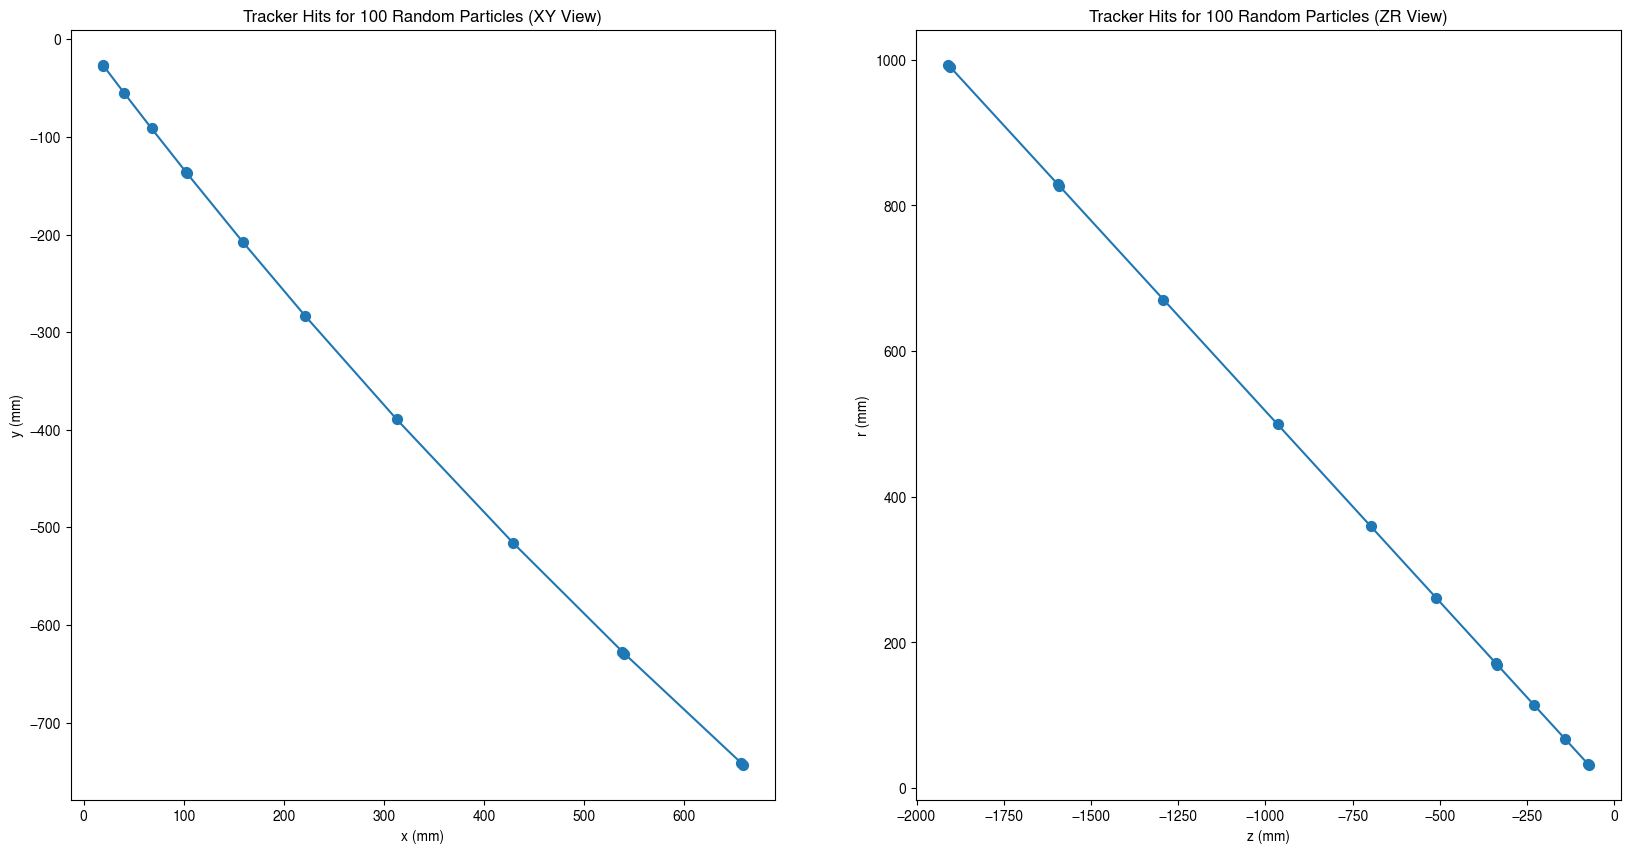

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in MT_tracker_reco_particles.index:
    particle_hits = MT_hits[MT_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()